In [ ]:
# اتصال به Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# نصب کتابخانه‌های مورد نیاز
!pip install -q pyarrow pandas numpy matplotlib psutil


In [ ]:
# تعریف dk_text.py به صورت inline (جایگزین فایل خارجی)
import re

PLACEHOLDER_BRAND = 'متفرقه'

_AR_YEH    = re.compile(r'\u064A')
_AR_KAF    = re.compile(r'\u0643')
_HAMZA     = re.compile(r'[\u0623\u0625\u0671]')
_FA_DIGIT  = re.compile(r'[\u06F0-\u06F9]')
_AR_DIGIT  = re.compile(r'[\u0660-\u0669]')
_DIAC      = re.compile(r'[\u064B-\u0652]')
_TATWEEL   = re.compile(r'\u0640')
_ZWNJ      = re.compile(r'\u200C')
_REPEAT    = re.compile(r'([^\W\d_])\1{2,}')
_SPACES    = re.compile(r'\s+')

_FA_DIGIT_MAP = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')
_AR_DIGIT_MAP = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return text
    text = _AR_YEH.sub('\u06CC', text)   # arabic yeh -> persian yeh
    text = _AR_KAF.sub('\u06A9', text)   # arabic kaf -> persian kaf
    text = _HAMZA.sub('\u0627', text)    # hamza forms -> alef
    text = text.translate(_FA_DIGIT_MAP) # persian digits -> ascii
    text = text.translate(_AR_DIGIT_MAP) # arabic digits -> ascii
    text = _DIAC.sub('', text)           # strip diacritics
    text = _TATWEEL.sub('', text)        # strip tatweel
    text = _ZWNJ.sub(' ', text)          # ZWNJ -> space
    text = _REPEAT.sub(r'\1\1', text)   # 3+ repeated -> 2
    text = _SPACES.sub(' ', text).strip()
    return text

print('dk_text تعریف شد')


dk_text تعریف شد


In [ ]:
# تنظیم مسیرها - داده‌ها باید در این مسیر در Google Drive باشند
from pathlib import Path

# مسیر پوشه داده‌ها در Drive را اینجا تنظیم کنید
DATA_DIR = Path('/content/drive/MyDrive/digikala_data')  # <-- اگر لازم است تغییر دهید

PRODUCTS_CSV      = DATA_DIR / 'digikala-products.csv'
COMMENTS_CSV      = DATA_DIR / 'digikala-comments.csv'
PRODUCTS_WORK_PQ  = DATA_DIR / 'products_work.parquet'
COMMENTS_WORK_PQ  = DATA_DIR / 'comments_work.parquet'

# بررسی وجود فایل‌ها
for p in [PRODUCTS_CSV, COMMENTS_CSV]:
    status = '✅ موجود' if p.exists() else '❌ پیدا نشد'
    print(f'{p.name}: {status}')


digikala-products.csv: ❌ پیدا نشد
digikala-comments.csv: ❌ پیدا نشد


# پروژه دستیار خرید دیجی‌کالا — آماده‌سازی داده

این نوت‌بوک داده خام محصولات و نظرات را بررسی و پاک‌سازی می‌کند و دو جدول کاری
`products_work.parquet` و `comments_work.parquet` را می‌سازد.

ساخت خود سیستم در `ali-02-architecture.ipynb` انجام می‌شود.

In [ ]:
"""Digikala shopping assistant - data preparation.

Turns the two raw CSVs into the working tables consumed by
ali-02-architecture.ipynb.
"""

import gc
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")


# ============================================================
# Data paths
# ============================================================

# فایل‌ها مستقیماً داخل MyDrive هستند
DATA_DIR = Path("/content/drive/MyDrive")

PRODUCTS_CSV = DATA_DIR / "digikala-products.csv"
COMMENTS_CSV = DATA_DIR / "digikala-comments.csv"

PRODUCTS_WORK_PQ = DATA_DIR / "products_work.parquet"
COMMENTS_WORK_PQ = DATA_DIR / "comments_work.parquet"


# ============================================================
# Pandas settings
# ============================================================

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)


# ============================================================
# System information
# ============================================================

print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)

print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)

try:
    import psutil

    ram_available = psutil.virtual_memory().available / 1024**3
    print(f"RAM    : {ram_available:.1f} GB available")

except ImportError:
    print("RAM    : psutil not installed")


try:
    import torch

    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_name(0)
        print("GPU    :", gpu)
    else:
        print("GPU    : none (CPU only)")

except ImportError:
    print("GPU    : torch not installed")


# ============================================================
# Check files
# ============================================================

print("\n" + "=" * 60)
print("CHECKING DATA FILES")
print("=" * 60)

for path in (PRODUCTS_CSV, COMMENTS_CSV):

    print(f"\nFile: {path}")

    if not path.exists():
        print("❌ NOT FOUND")
        print("Expected location:")
        print(path)
        raise FileNotFoundError(
            f"\nFile not found:\n{path}\n\n"
            "Make sure the CSV file is directly inside MyDrive."
        )

    size_gb = path.stat().st_size / 1024**3

    print("✅ Found")
    print(f"Size: {size_gb:.2f} GB")


# ============================================================
# Final paths
# ============================================================

print("\n" + "=" * 60)
print("PATHS")
print("=" * 60)

print("DATA_DIR        :", DATA_DIR)
print("PRODUCTS_CSV    :", PRODUCTS_CSV)
print("COMMENTS_CSV    :", COMMENTS_CSV)
print("PRODUCTS_WORK   :", PRODUCTS_WORK_PQ)
print("COMMENTS_WORK   :", COMMENTS_WORK_PQ)

print("\n✅ All files are ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SYSTEM INFORMATION
Python : 3.13.15
Pandas : 2.2.3
RAM    : 11.5 GB available
GPU    : Tesla T4

CHECKING DATA FILES

File: /content/drive/MyDrive/digikala-products.csv
✅ Found
Size: 0.24 GB

File: /content/drive/MyDrive/digikala-comments.csv
✅ Found
Size: 1.19 GB

PATHS
DATA_DIR        : /content/drive/MyDrive
PRODUCTS_CSV    : /content/drive/MyDrive/digikala-products.csv
COMMENTS_CSV    : /content/drive/MyDrive/digikala-comments.csv
PRODUCTS_WORK   : /content/drive/MyDrive/products_work.parquet
COMMENTS_WORK   : /content/drive/MyDrive/comments_work.parquet

✅ All files are ready.


## ۱. بارگذاری

نوع هر ستون صریح داده می‌شود. اگر پندس خودش حدس بزند، وجود یک مقدار خالی در یک
ستون عددی کل ستون را به اعشاری تبدیل می‌کند و بعداً اتصال `id` بین دو جدول
بی‌سروصدا شکست می‌خورد.

In [ ]:
PRODUCT_DTYPES = {
    "id": "int64", "title_fa": "string", "Rate": "int16", "Rate_cnt": "int32",
    "Category1": "string", "Category2": "string", "Brand": "string",
    "Price": "int64",              # rial prices can exceed the int32 range
    "Seller": "string", "Is_Fake": "bool",
    "min_price_last_month": "int64", "sub_category": "string",
}
COMMENT_DTYPES = {
    "id": "int64", "title": "string", "body": "string",
    "created_at": "string",        # Jalali date text; pandas cannot parse it
    "rate": "float32",             # fractional values exist, so not an int
    "recommendation_status": "string", "is_buyer": "bool",
    "product_id": "int64",         # must match products.id exactly
    "advantages": "string", "disadvantages": "string",
    "likes": "int32", "dislikes": "int32",
    "seller_title": "string", "seller_code": "string",
    "true_to_size_rate": "string",
}

started = time.time()
# utf-8-sig: both files carry a UTF-8 BOM. pandas 3 strips it anyway, but
# stating it keeps the code portable to csv/polars/older pandas.
products = pd.read_csv(PRODUCTS_CSV, encoding="utf-8-sig", dtype=PRODUCT_DTYPES)
comments = pd.read_csv(COMMENTS_CSV, encoding="utf-8-sig", dtype=COMMENT_DTYPES)
print(f"loaded in {time.time() - started:.0f}s")
print(f"products: {len(products):>9,} rows x {products.shape[1]} cols")
print(f"comments: {len(comments):>9,} rows x {comments.shape[1]} cols")

loaded in 57s
products: 1,283,496 rows x 12 cols
comments: 6,156,289 rows x 15 cols


## ۲. کیفیت داده

نسبت مقادیر خالی به تنهایی گمراه‌کننده است: در این داده «گمشده» گاهی با عدد صفر و
گاهی با کلمه «متفرقه» ثبت شده، که هیچ‌کدام را `isna` نمی‌گیرد. برای همین به توزیع
مقادیر نگاه می‌کنیم نه فقط به آمار خالی‌ها.

In [ ]:
def audit_column(frame: pd.DataFrame, column: str, top: int = 6) -> None:
    """Show a column's distribution, exposing sentinels and placeholder values."""
    series = frame[column]
    print(f"--- {column} ({series.dtype}) ---")
    print(f"NaN {series.isna().mean() * 100:5.2f}%   unique {series.nunique():,}")
    if pd.api.types.is_numeric_dtype(series):
        print(f"zeros {(series == 0).sum():,}")
        print(series.describe().to_string())
    else:
        print(series.value_counts(dropna=False).head(top).to_string())
    print()


for column in ["Rate", "Rate_cnt", "Price", "min_price_last_month",
               "Category1", "Category2", "Brand", "sub_category"]:
    audit_column(products, column)

--- Rate (int16) ---
NaN  0.00%   unique 51
zeros 799,172
count    1.283496e+06
mean     3.013031e+01
std      3.991098e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      8.000000e+01
max      1.000000e+02

--- Rate_cnt (int32) ---
NaN  0.00%   unique 3,123
zeros 799,151
count    1.283496e+06
mean     2.073829e+01
std      2.182101e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.000000e+00
max      3.043800e+04

--- Price (int64) ---
NaN  0.00%   unique 46,810
zeros 223
count    1.283496e+06
mean     8.491273e+06
std      4.663222e+07
min      0.000000e+00
25%      7.000000e+05
50%      1.560000e+06
75%      4.450000e+06
max      8.499990e+09

--- min_price_last_month (int64) ---
NaN  0.00%   unique 16,857
zeros 1,208,195
count    1.283496e+06
mean     4.212147e+05
std      1.202546e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.645500e+09

--- Category1 (string) ---
NaN

In [ ]:
# Rate == 0 needs interpreting before any ranking uses it: real zero score, or
# "nobody has rated this yet"?
no_value = products["Rate"] == 0
no_count = products["Rate_cnt"] == 0
print("Rate=0 & Rate_cnt=0 :", (no_value & no_count).sum())
print("Rate=0 & Rate_cnt>0 :", (no_value & ~no_count).sum())
print("Rate>0 & Rate_cnt=0 :", (~no_value & no_count).sum())

rated = products.loc[products["Rate_cnt"] > 0, "Rate"]
print(f"\ndistinct values among rated products: {rated.nunique()}")
print(f"all even: {bool((rated % 2 == 0).all())}   range: {rated.min()}-{rated.max()}")

Rate=0 & Rate_cnt=0 : 799151
Rate=0 & Rate_cnt>0 : 21
Rate>0 & Rate_cnt=0 : 0

distinct values among rated products: 51
all even: True   range: 0-100


In [ ]:
# recommendation_status is the target of the classification task, so its exact
# distribution decides how the three classes are defined.
print("recommendation_status:")
print(comments["recommendation_status"].value_counts(dropna=False).to_string())

print("\nrate:")
print(comments["rate"].value_counts(dropna=False).head(8).to_string())

body_len = comments["body"].str.len()
print(f"\nbody length: median {body_len.median():.0f} chars, "
      f"p90 {body_len.quantile(0.9):.0f}, max {body_len.max():.0f}")
print(f"bodies under 10 chars: {(body_len < 10).sum():,}")
print(f"titles present       : {comments['title'].notna().mean() * 100:.1f}%")

recommendation_status:
recommendation_status
recommended        4162839
<NA>                894426
no_idea             594121
not_recommended     504903

rate:
rate
5.0    2398801
4.0    1515723
3.0     958799
0.0     529098
1.0     327662
2.0     198077
4.5      13479
3.5      12207

body length: median 29 chars, p90 106, max 4000
bodies under 10 chars: 671,959
titles present       : 53.5%


## ۳. حذف تکراری‌ها

۲۶٪ ردیف‌های جدول محصولات شناسه تکراری دارند. قبل از حذف باید بدانیم کپی دقیق‌اند
یا نسخه‌های متفاوت، چون در حالت دوم حذف ساده باعث از دست رفتن اطلاعات می‌شود.

In [ ]:
dup_by_id = products.duplicated(subset=["id"], keep="first").sum()
dup_full = products.duplicated(keep="first").sum()
print(f"rows repeating an id : {dup_by_id:,}")
print(f"exact copies         : {dup_full:,}")
print(f"conflicting rows     : {dup_by_id - dup_full:,}")

# Collapse exact copies first; whatever still shares an id must differ somewhere.
survivors = products.drop_duplicates()
conflicts = survivors.loc[survivors.duplicated(subset=["id"], keep=False)]
varying = conflicts.groupby("id").nunique().gt(1).sum()
print("\ncolumns that differ between versions:")
print(varying[varying > 0].sort_values(ascending=False).to_string())

spread = conflicts.groupby("id")["Price"].agg(["min", "max"])
relative = (spread["max"] - spread["min"]) / spread["min"].replace(0, np.nan)
print(f"\nrelative price spread: median {relative.median():.3f}, "
      f"p90 {relative.quantile(0.9):.3f}, max {relative.max():.2f}")

rows repeating an id : 335,144
exact copies         : 323,129
conflicting rows     : 12,015

columns that differ between versions:
Price                   8254
Seller                  3994
Rate_cnt                3251
min_price_last_month    1458
sub_category             757
Rate                     646
title_fa                   6
Brand                      2

relative price spread: median 0.017, p90 0.250, max 5.03


In [ ]:
# Keep the most-rated version of each product; tie-break towards the row that
# carries last-month price data, then towards the cheapest listing, since the
# product being built is a shopping assistant.
products_clean = (
    products.sort_values(
        ["id", "Rate_cnt", "min_price_last_month", "Price"],
        ascending=[True, False, False, True],
    )
    .drop_duplicates(subset=["id"], keep="first")
    .reset_index(drop=True)
)
comments_clean = (
    comments.sort_values(["id", "likes"], ascending=[True, False])
    .drop_duplicates(subset=["id"], keep="first")
    .reset_index(drop=True)
)
print(f"products: {len(products):,} -> {len(products_clean):,}")
print(f"comments: {len(comments):,} -> {len(comments_clean):,}")

linked = comments_clean["product_id"].isin(products_clean["id"])
print(f"reviews resolving to a catalogue product: {linked.mean() * 100:.2f}%")

assert products_clean["id"].is_unique
assert comments_clean["id"].is_unique
assert linked.all(), "orphan review found"

# Kept for the summary tables and charts at the end of the notebook.
RAW_COUNTS = {"products": len(products), "comments": len(comments)}

del products, comments
gc.collect()

products: 1,283,496 -> 948,352
comments: 6,156,289 -> 6,153,060
reviews resolving to a catalogue product: 100.00%


79

## ۴. آمار نظرات هر محصول

آمار برای همه محصولات نظردار یک بار حساب می‌شود تا مقایسه آستانه‌های مختلف بدون
محاسبه دوباره ممکن باشد.

`n_substantive` معیار صادقانه‌تری از `n_reviews` است: یک‌دهم نظرات زیر ده کاراکترند
و به سؤالی مثل «ایرادهای پرتکرار چیست؟» جواب نمی‌دهند.

In [ ]:
# One review carries rate 2500, which pushed a product mean to 20.7. Out-of-range
# values become NaN rather than being rescaled: the intended value is unknowable.
print(f"reviews with rate above 5: {comments_clean['rate'].gt(5).sum():,}")
comments_clean["rate"] = comments_clean["rate"].where(comments_clean["rate"].between(0, 5))

# Helper columns are built here rather than as lambdas inside agg, which would
# call back into Python once per group.
comments_clean["rate_valid"] = comments_clean["rate"].where(comments_clean["rate"] > 0)
comments_clean["is_rec"] = comments_clean["recommendation_status"].eq("recommended")
comments_clean["is_not_rec"] = comments_clean["recommendation_status"].eq("not_recommended")
comments_clean["has_status"] = comments_clean["recommendation_status"].notna()
comments_clean["body_len"] = comments_clean["body"].str.len().fillna(0).astype("int32")
comments_clean["is_substantive"] = comments_clean["body_len"] >= 30
comments_clean["has_pros"] = comments_clean["advantages"].notna()
comments_clean["has_cons"] = comments_clean["disadvantages"].notna()

stats = comments_clean.groupby("product_id").agg(
    n_reviews=("id", "size"),
    n_substantive=("is_substantive", "sum"),
    n_rated=("rate_valid", "count"),
    mean_rate=("rate_valid", "mean"),
    n_with_status=("has_status", "sum"),
    n_recommended=("is_rec", "sum"),
    n_not_recommended=("is_not_rec", "sum"),
    n_pros=("has_pros", "sum"),
    n_cons=("has_cons", "sum"),
    mean_body_len=("body_len", "mean"),
    n_buyers=("is_buyer", "sum"),
)
# Denominator is reviews that expressed a status, not all reviews: 14.5% are blank.
stats["rec_ratio"] = stats["n_recommended"] / stats["n_with_status"].replace(0, np.nan)
stats["substantive_ratio"] = stats["n_substantive"] / stats["n_reviews"]

print(f"\n{len(stats):,} products carry at least one review "
      f"({len(stats) / len(products_clean) * 100:.1f}% of the catalogue)")
print(stats[["n_reviews", "n_substantive", "mean_rate", "rec_ratio"]]
      .describe(percentiles=[0.1, 0.5, 0.9]).round(2).to_string())

reviews with rate above 5: 1

331,599 products carry at least one review (35.0% of the catalogue)
       n_reviews  n_substantive  mean_rate  rec_ratio
count  331599.00      331599.00  324789.00   309258.0
mean       18.56           9.10       3.93       0.74
std        40.90          19.74       0.88       0.31
min         1.00           0.00       0.05        0.0
10%         1.00           0.00       3.00        0.0
50%         4.00           2.00       4.00       0.85
90%        46.00          24.00       5.00        1.0
max       233.00         169.00       5.00        1.0


In [ ]:
def threshold_report(stats: pd.DataFrame, thresholds: tuple[int, ...]) -> pd.DataFrame:
    """Compare minimum-review thresholds on coverage and on usable evidence."""
    total = stats["n_reviews"].sum()
    rows = []
    for threshold in thresholds:
        kept = stats.loc[stats["n_reviews"] >= threshold]
        rows.append({
            "threshold": threshold,
            "products": len(kept),
            "pct_reviews": kept["n_reviews"].sum() / total * 100,
            "median_substantive": kept["n_substantive"].median(),
            "p10_substantive": kept["n_substantive"].quantile(0.10),
            "pct_with_5plus": (kept["n_substantive"] >= 5).mean() * 100,
        })
    return pd.DataFrame(rows).set_index("threshold").round(1)


print(threshold_report(stats, (1, 3, 5, 10, 20, 30)).to_string())

           products  pct_reviews  median_substantive  p10_substantive  pct_with_5plus
threshold                                                                            
1            331599        100.0                 2.0              0.0            31.4
3            194529         97.0                 5.0              1.0            53.4
5            147711         94.4                 8.0              2.0            70.4
10            98051         89.1                14.0              5.0            93.4
20            61968         81.1                26.0             11.0            99.7
30            46465         75.1                37.0             16.0           100.0


## ۵. ساخت جدول کاری

هیچ محصول نظرداری حذف نمی‌شود. به‌جای آستانه‌گذاری، دو مکانیزم گذاشته شده:

- `evidence_tier` مشخص می‌کند سیستم تا چه حد مجاز است تعمیم دهد
- `rec_score` نسبت رضایت را متناسب با تعداد نظر به میانگین کل منقبض می‌کند

In [ ]:
RICH_EVIDENCE = 10       # substantive reviews needed to generalise
MODERATE_EVIDENCE = 5    # below this, quote rather than generalise
PRIOR_WEIGHT = 10        # shrinkage strength, in "imaginary reviews"

products_work = (
    products_clean.merge(stats, left_on="id", right_index=True, how="inner")
    .reset_index(drop=True)
)

global_rec = comments_clean["is_rec"].sum() / comments_clean["has_status"].sum()
global_rate = comments_clean["rate_valid"].mean()
print(f"global priors: rec_ratio {global_rec:.4f}, mean_rate {global_rate:.4f}")


def shrink(observed, support, prior, weight):
    """Pull a per-product ratio towards the global prior, weighted by support.

    A ratio measured on one review lands near the prior; one measured on
    hundreds barely moves.
    """
    return (support * observed.fillna(prior) + weight * prior) / (support + weight)


products_work["rec_score"] = shrink(
    products_work["rec_ratio"], products_work["n_with_status"], global_rec, PRIOR_WEIGHT)
products_work["rate_score"] = shrink(
    products_work["mean_rate"], products_work["n_rated"], global_rate, PRIOR_WEIGHT)

# pd.cut bins are right-inclusive, so the edges sit one below each constant.
products_work["evidence_tier"] = pd.cut(
    products_work["n_substantive"],
    bins=[-1, 0, MODERATE_EVIDENCE - 1, RICH_EVIDENCE - 1, np.inf],
    labels=["none", "thin", "moderate", "rich"],
)
assert products_work["evidence_tier"].notna().all(), "pd.cut left a product unlabelled"

comments_work = comments_clean.reset_index(drop=True)
print(f"\nworking set: {len(products_work):,} products, {len(comments_work):,} reviews")
print(products_work["evidence_tier"].value_counts().sort_index().to_string())

global priors: rec_ratio 0.7912, mean_rate 3.9909

working set: 331,599 products, 6,153,060 reviews
evidence_tier
none         58238
thin        169395
moderate     39382
rich         64584


In [ ]:
columns = ["title_fa", "n_reviews", "n_with_status", "rec_ratio", "rec_score"]
print("top 10 by raw rec_ratio:")
print(products_work.nlargest(10, "rec_ratio")[columns].to_string(index=False))
print("\ntop 10 after shrinkage:")
print(products_work.nlargest(10, "rec_score")[columns].to_string(index=False))

perfect = products_work["rec_ratio"] == 1.0
few = products_work["n_with_status"] <= 3
print(f"\nproducts at a perfect 100%: {perfect.sum():,}")
print(f"  of those, backed by <=3 rated reviews: {(perfect & few).sum():,}")

top 10 by raw rec_ratio:
                                         title_fa  n_reviews  n_with_status  rec_ratio  rec_score
ساعت مچی دیجیتالی مردانه کاسیو جی شاک GD-100-1BDR          9              6        1.0   0.869482
 آموزش تصویری ارف کودکان نشر دنیای نرم افزار سینا          1              1        1.0   0.810156
  لیزر بدن رمینگتون مدل IPL4000 مناسب برای بانوان          2              1        1.0   0.810156
             آلبوم موسیقی جشن تنهایی - شهاب رمضان          3              2        1.0   0.825976
       آلبوم موسیقی لحظه های بی هوا - میثم مروستی          1              1        1.0   0.810156
             آلبوم موسیقی زیر بارون 2 - امیر طبری          1              1        1.0   0.810156
            آلبوم موسیقی خاطرات مبهم - رضا یزدانی          3              2        1.0   0.825976
         آلبوم موسیقی حریق خزان اثر علیرضا قربانی          4              3        1.0   0.839363
            آلبوم موسیقی دود عود - محمدرضا شجریان          6              5        1.0   0.86

## ۶. نرمال‌سازی متن فارسی

«ی» و «ک» عربی روی صفحه با فارسی یکسان دیده می‌شوند ولی کاراکتر متفاوتی هستند.
شیوعشان در داده حدود یک درصد است، اما اگر پرس‌وجوی کاربر با کیبورد عربی تایپ شود،
همان یک درصد کافی است که جست‌وجو هیچ نتیجه‌ای برنگرداند.

تابع `normalize_text` در `dk_text.py` قرار دارد تا داده و پرس‌وجو از یک مسیر رد شوند.

In [ ]:
# pandas 3 routes .str.contains to PyArrow's RE2 engine, which supports neither
# unicode escapes nor backreferences, so the patterns are compiled with re here.
PATTERNS = {
    "arabic yeh": r"\u064A",
    "arabic kaf": r"\u0643",
    "hamza forms": r"[\u0623\u0625\u0671]",
    "persian digits": r"[\u06F0-\u06F9]",
    "arabic digits": r"[\u0660-\u0669]",
    "diacritics": r"[\u064B-\u0652]",
    "tatweel": r"\u0640",
    "zero-width non-joiner": r"\u200C",
    "3+ repeated letters": r"([^\W\d_])\1{2,}",
    "latin letters": r"[A-Za-z]",
}

sample = comments_work["body"].dropna().sample(500_000, random_state=42)
for label, pattern in PATTERNS.items():
    compiled = re.compile(pattern)
    hits = sample.map(lambda text: compiled.search(text) is not None).sum()
    print(f"{label:24s}: {hits:>7,}  ({hits / len(sample) * 100:5.2f}%)")

arabic yeh              :   3,969  ( 0.79%)
arabic kaf              :   2,069  ( 0.41%)
hamza forms             :     656  ( 0.13%)
persian digits          :  15,909  ( 3.18%)
arabic digits           :     105  ( 0.02%)
diacritics              :   3,542  ( 0.71%)
tatweel                 :     207  ( 0.04%)
zero-width non-joiner   :  15,826  ( 3.17%)
3+ repeated letters     :  10,568  ( 2.11%)
latin letters           :   3,283  ( 0.66%)


In [ ]:
# Regression suite for normalize_text. The third case guards the digit trap: a
# naive elongation rule would turn the price 1000000 into 10.
CASES = [
    "كيف زنانه خيلي خوبه",
    "قيمتش ۱۲۵۰۰۰۰ تومان بود",
    "قیمت 1000000 تومان",
    "عاااااالیییییی بووووود",
    "مُحصولِ خوبی بود",
    "کتـــاب خوبی بود",
    "می‌ رود  و   می‌آید",
]
for case in CASES:
    print(f"{case:30s} ->  {normalize_text(case)}")

كيف زنانه خيلي خوبه            ->  کیف زنانه خیلی خوبه
قيمتش ۱۲۵۰۰۰۰ تومان بود        ->  قیمتش 1250000 تومان بود
قیمت 1000000 تومان             ->  قیمت 1000000 تومان
عاااااالیییییی بووووود         ->  عاالیی بوود
مُحصولِ خوبی بود               ->  محصول خوبی بود
کتـــاب خوبی بود               ->  کتاب خوبی بود
می‌ رود  و   می‌آید            ->  می رود و می آید


In [ ]:
# Originals are kept: a review quoted back to the user must show what that user
# actually wrote. The _norm columns exist only for matching and embedding.
started = time.time()
for source, target in (("title_fa", "title_norm"), ("Brand", "brand_norm"),
                       ("Category1", "cat1_norm"), ("Category2", "cat2_norm")):
    products_work[target] = products_work[source].map(normalize_text, na_action="ignore")
for source, target in (("body", "body_norm"), ("title", "review_title_norm")):
    comments_work[target] = comments_work[source].map(normalize_text, na_action="ignore")
print(f"normalised in {time.time() - started:.0f}s")

# Categories are appended because titles are mostly model codes and rarely
# contain the words a shopper types. The placeholder brand is dropped: it marks
# 56% of rows and would make all of them look alike to a retriever.
brand = products_work["brand_norm"].where(
    products_work["brand_norm"] != PLACEHOLDER_BRAND, "")
search_text = products_work["title_norm"].fillna("")
for part in (products_work["cat1_norm"], products_work["cat2_norm"], brand):
    search_text = search_text.str.cat(part.fillna(""), sep=" ")
products_work["search_text"] = (
    search_text.str.replace(r"\s+", " ", regex=True).str.strip()
)
assert products_work["search_text"].str.len().gt(0).all()

products_work.to_parquet(PRODUCTS_WORK_PQ, index=False, compression="zstd")
comments_work.to_parquet(COMMENTS_WORK_PQ, index=False, compression="zstd")
print(f"saved {PRODUCTS_WORK_PQ.name} ({PRODUCTS_WORK_PQ.stat().st_size / 1024**2:.0f} MB)")
print(f"saved {COMMENTS_WORK_PQ.name} ({COMMENTS_WORK_PQ.stat().st_size / 1024**2:.0f} MB)")

normalised in 227s
saved products_work.parquet (30 MB)
saved comments_work.parquet (451 MB)


## ۷. جدول‌ها و نمودارهای

خروجی این بخش در پوشه `figures/` ذخیره می‌شود و مستقیماً در اسلایدها قابل استفاده است.


In [ ]:
import matplotlib.pyplot as plt

FIGURE_DIR = DATA_DIR / "figures"  # ذخیره در Drive
FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
})

BLUE, ORANGE, GREY, GREEN, RED = "#2b6cb0", "#dd6b20", "#a0aec0", "#38a169", "#e53e3e"


def save(fig, name: str) -> None:
    """Write a figure to figures/ so it can be dropped into the slide deck."""
    fig.savefig(FIGURE_DIR / f"{name}.png")
    print("saved figures/" + name + ".png")


# --- Table 1: what each stage of the pipeline removed --------------------
pipeline = pd.DataFrame(
    [
        {"stage": "raw CSV",
         "products": RAW_COUNTS["products"], "reviews": RAW_COUNTS["comments"]},
        {"stage": "after de-duplication",
         "products": len(products_clean), "reviews": len(comments_clean)},
        {"stage": "with at least one review",
         "products": len(products_work), "reviews": len(comments_work)},
    ]
).set_index("stage")
pipeline["products %"] = (pipeline["products"] / RAW_COUNTS["products"] * 100).round(1)
pipeline["reviews %"] = (pipeline["reviews"] / RAW_COUNTS["comments"] * 100).round(1)
print("TABLE 1 - pipeline")
print(pipeline.to_string())
pipeline.to_csv(FIGURE_DIR / "table1_pipeline.csv")

TABLE 1 - pipeline
                          products  reviews  products %  reviews %
stage                                                             
raw CSV                    1283496  6156289       100.0      100.0
after de-duplication        948352  6153060        73.9       99.9
with at least one review    331599  6153060        25.8       99.9


In [ ]:
# --- Table 2: missing data that isaN does not see ------------------------
# Each of these columns records "unknown" as a value rather than as a null,
# so the reported null rate understates the real gap.
SENTINELS = [
    ("Rate", products_clean["Rate"] == 0, "0 = nobody rated"),
    ("Rate_cnt", products_clean["Rate_cnt"] == 0, "0 = nobody rated"),
    ("min_price_last_month", products_clean["min_price_last_month"] == 0, "0 = no data"),
    ("Brand", products_clean["Brand"] == PLACEHOLDER_BRAND, "متفرقه = no brand"),
    ("Category2", products_clean["Category2"].isna(), "genuinely null"),
]
quality = pd.DataFrame([
    {
        "column": name,
        "reported null %": round(products_clean[name].isna().mean() * 100, 2),
        "true missing %": round(mask.mean() * 100, 2),
        "encoded as": note,
    }
    for name, mask, note in SENTINELS
]).set_index("column")
print("TABLE 2 - missing data hidden behind sentinel values")
print(quality.to_string())
quality.to_csv(FIGURE_DIR / "table2_missing.csv")

TABLE 2 - missing data hidden behind sentinel values
                      reported null %  true missing %         encoded as
column                                                                  
Rate                             0.00           61.94   0 = nobody rated
Rate_cnt                         0.00           61.94   0 = nobody rated
min_price_last_month             0.00           94.15        0 = no data
Brand                            0.00           55.89  متفرقه = no brand
Category2                       19.12           19.12     genuinely null


saved figures/fig1_data_quality.png


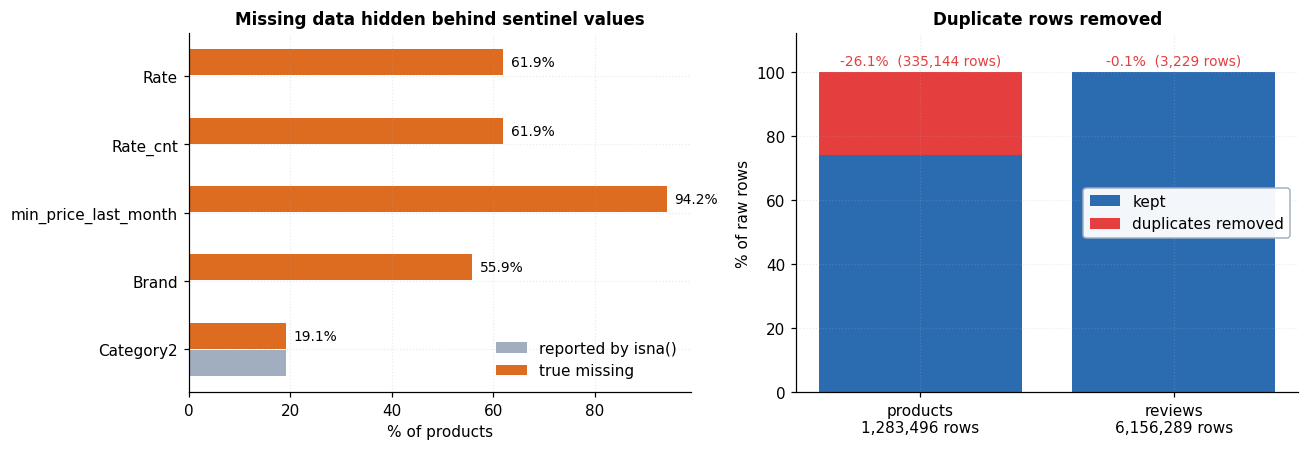

In [ ]:
# --- Figure 1: data quality ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
positions = np.arange(len(quality))
ax.barh(positions + 0.2, quality["reported null %"], height=0.38,
        color=GREY, label="reported by isna()")
ax.barh(positions - 0.2, quality["true missing %"], height=0.38,
        color=ORANGE, label="true missing")
ax.set_yticks(positions)
ax.set_yticklabels(quality.index)
ax.invert_yaxis()
ax.set_xlabel("% of products")
ax.set_title("Missing data hidden behind sentinel values")
ax.legend(frameon=False, loc="lower right")
for y, value in zip(positions, quality["true missing %"]):
    ax.text(value + 1.5, y - 0.2, f"{value:.1f}%", va="center", fontsize=9)

ax = axes[1]
# Shown as percentages: the two tables differ by an order of magnitude in size,
# so absolute counts would hide the product duplication entirely.
kept = np.array([len(products_clean), len(comments_clean)], dtype=float)
raw = np.array([RAW_COUNTS["products"], RAW_COUNTS["comments"]], dtype=float)
kept_pct = kept / raw * 100
labels = [f"products\n{int(raw[0]):,} rows", f"reviews\n{int(raw[1]):,} rows"]
ax.bar(labels, kept_pct, color=BLUE, label="kept")
ax.bar(labels, 100 - kept_pct, bottom=kept_pct, color=RED, label="duplicates removed")
for i, pct in enumerate(kept_pct):
    ax.text(i, 101, f"-{100 - pct:.1f}%  ({int(raw[i] - kept[i]):,} rows)",
            ha="center", va="bottom", fontsize=9, color=RED)
ax.set_ylim(0, 112)
ax.set_ylabel("% of raw rows")
ax.set_title("Duplicate rows removed")
# Framed on purpose: the "kept" swatch sits on top of a blue bar.
ax.legend(loc="center right", frameon=True, facecolor="white", framealpha=0.95,
          edgecolor=GREY)

fig.tight_layout()
save(fig, "fig1_data_quality")
plt.show()

saved figures/fig2_review_distribution.png


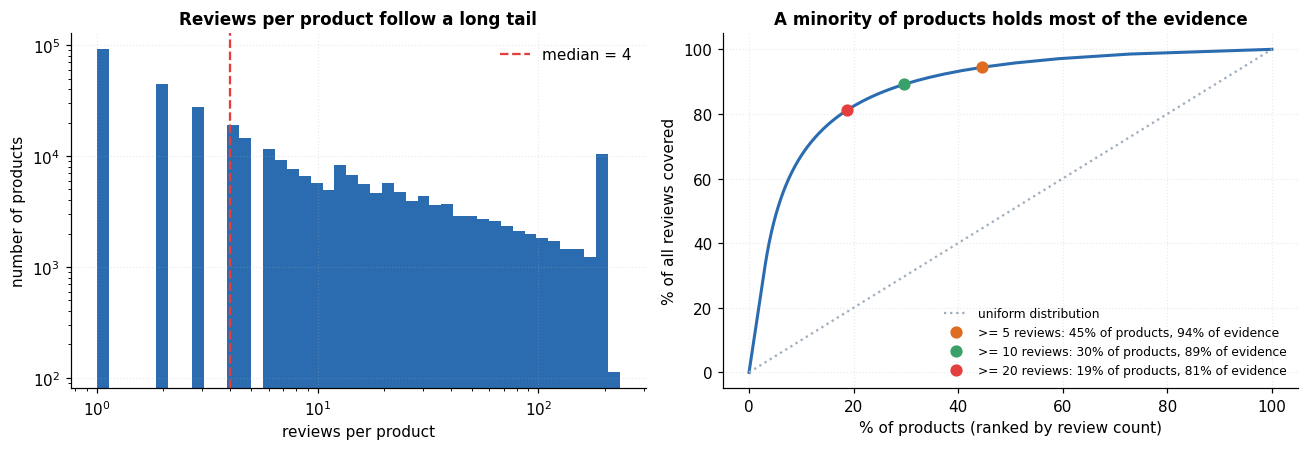

In [ ]:
# --- Figure 2: how reviews are distributed across products ---------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
bins = np.logspace(0, np.log10(stats["n_reviews"].max()), 45)
ax.hist(stats["n_reviews"], bins=bins, color=BLUE)
ax.set_xscale("log")
ax.set_yscale("log")
ax.axvline(stats["n_reviews"].median(), color=RED, linestyle="--",
           label=f"median = {stats['n_reviews'].median():.0f}")
ax.set_xlabel("reviews per product")
ax.set_ylabel("number of products")
ax.set_title("Reviews per product follow a long tail")
ax.legend(frameon=False)

ax = axes[1]
ordered = np.sort(stats["n_reviews"].to_numpy())[::-1]
share_products = np.arange(1, len(ordered) + 1) / len(ordered) * 100
share_reviews = np.cumsum(ordered) / ordered.sum() * 100
ax.plot(share_products, share_reviews, color=BLUE, linewidth=2)
ax.plot([0, 100], [0, 100], color=GREY, linestyle=":", label="uniform distribution")
for threshold, colour in ((5, ORANGE), (10, GREEN), (20, RED)):
    kept = (stats["n_reviews"] >= threshold).sum()
    x = kept / len(stats) * 100
    y = stats.loc[stats["n_reviews"] >= threshold, "n_reviews"].sum() / ordered.sum() * 100
    ax.plot(x, y, "o", color=colour, markersize=7,
            label=f">= {threshold} reviews: {x:.0f}% of products, {y:.0f}% of evidence")
ax.set_xlabel("% of products (ranked by review count)")
ax.set_ylabel("% of all reviews covered")
ax.set_title("A minority of products holds most of the evidence")
ax.legend(frameon=False, fontsize=8, loc="lower right")

fig.tight_layout()
save(fig, "fig2_review_distribution")
plt.show()

saved figures/fig3_shrinkage.png


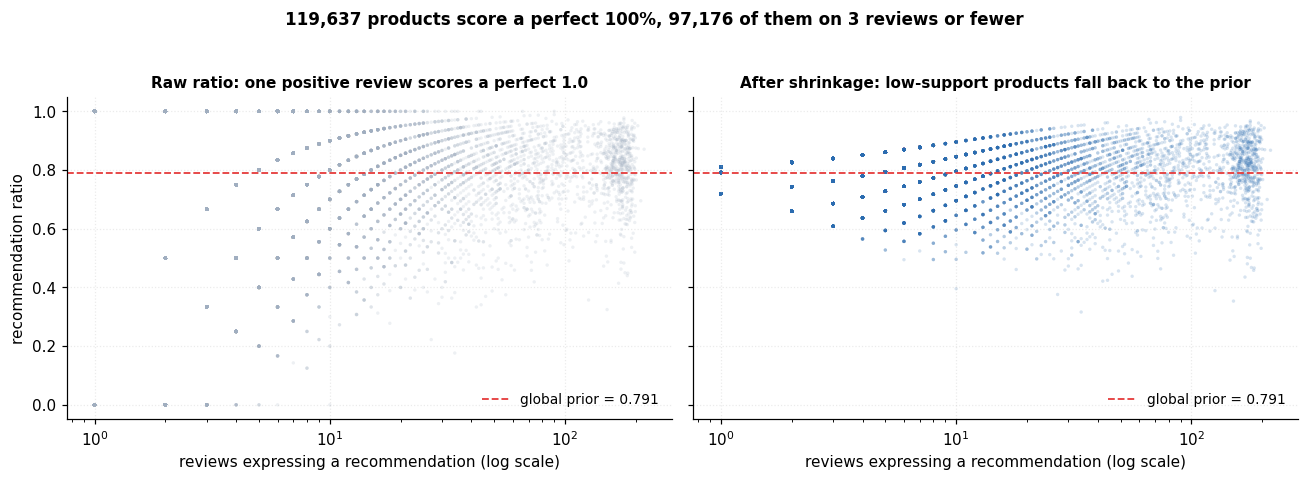

In [ ]:
# --- Figure 3: why the ranking score needs shrinkage ---------------------
# 15k points keep the scatter readable; the pattern is identical at full size.
sample = products_work.sample(15_000, random_state=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, column, title, colour in (
    (axes[0], "rec_ratio", "Raw ratio: one positive review scores a perfect 1.0", GREY),
    (axes[1], "rec_score", "After shrinkage: low-support products fall back to the prior", BLUE),
):
    ax.scatter(sample["n_with_status"].clip(lower=1), sample[column],
               s=5, alpha=0.18, color=colour, edgecolors="none")
    ax.axhline(global_rec, color=RED, linestyle="--", linewidth=1.2,
               label=f"global prior = {global_rec:.3f}")
    ax.set_xscale("log")
    ax.set_xlabel("reviews expressing a recommendation (log scale)")
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=False, loc="lower right", fontsize=9)
axes[0].set_ylabel("recommendation ratio")

perfect = products_work["rec_ratio"] == 1.0
few = products_work["n_with_status"] <= 3
fig.suptitle(
    f"{perfect.sum():,} products score a perfect 100%, "
    f"{(perfect & few).sum():,} of them on 3 reviews or fewer",
    fontsize=11, fontweight="bold", y=1.03,
)
fig.tight_layout()
save(fig, "fig3_shrinkage")
plt.show()

majority-class baseline Macro F1 = 0.2945
saved figures/fig4_target_and_tiers.png


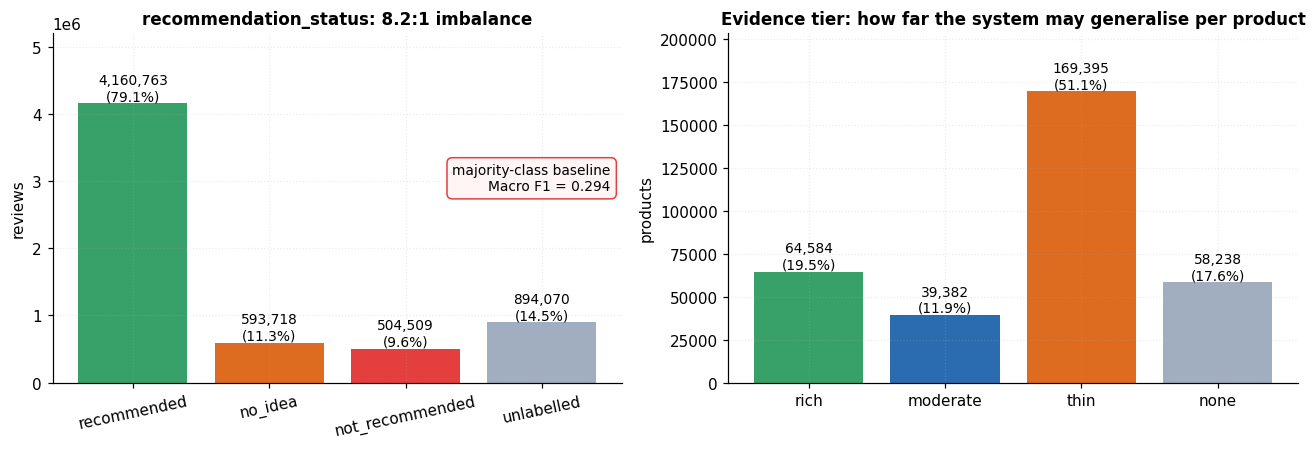

In [ ]:
# --- Figure 4: target variable and evidence tiers ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
order = ["recommended", "no_idea", "not_recommended"]
counts = comments_work["recommendation_status"].value_counts(dropna=False)
values = [int(counts.get(label, 0)) for label in order]
missing = int(len(comments_work) - sum(values))
labelled = sum(values)

# A model that always predicts the majority class scores F1 = 2p/(p+1) on that
# class and 0 on the other two, so Macro F1 is that divided by three.
majority = max(values) / labelled
baseline_macro_f1 = (2 * majority / (majority + 1)) / 3

bars = ax.bar(order + ["unlabelled"], values + [missing],
              color=[GREEN, ORANGE, RED, GREY])
for bar, value in zip(bars, values + [missing]):
    share = value / labelled * 100 if value != missing else value / len(comments_work) * 100
    note = f"{value:,}\n({share:.1f}%)"
    ax.text(bar.get_x() + bar.get_width() / 2, value, note,
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(values) * 1.25)
ax.set_ylabel("reviews")
ax.set_title(f"recommendation_status: {majority / (min(values) / labelled):.1f}:1 imbalance")
ax.tick_params(axis="x", rotation=12)
ax.text(0.98, 0.55,
        f"majority-class baseline\nMacro F1 = {baseline_macro_f1:.3f}",
        transform=ax.transAxes, ha="right", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff5f5", edgecolor=RED))
print(f"majority-class baseline Macro F1 = {baseline_macro_f1:.4f}")

ax = axes[1]
tiers = products_work["evidence_tier"].value_counts().reindex(
    ["rich", "moderate", "thin", "none"])
bars = ax.bar(tiers.index, tiers.to_numpy(), color=[GREEN, BLUE, ORANGE, GREY])
for bar, value in zip(bars, tiers.to_numpy()):
    ax.text(bar.get_x() + bar.get_width() / 2, value,
            f"{value:,}\n({value / len(products_work) * 100:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("products")
ax.set_ylim(0, tiers.max() * 1.2)
ax.set_title("Evidence tier: how far the system may generalise per product")

fig.tight_layout()
save(fig, "fig4_target_and_tiers")
plt.show()

saved figures/fig5_text_and_departments.png


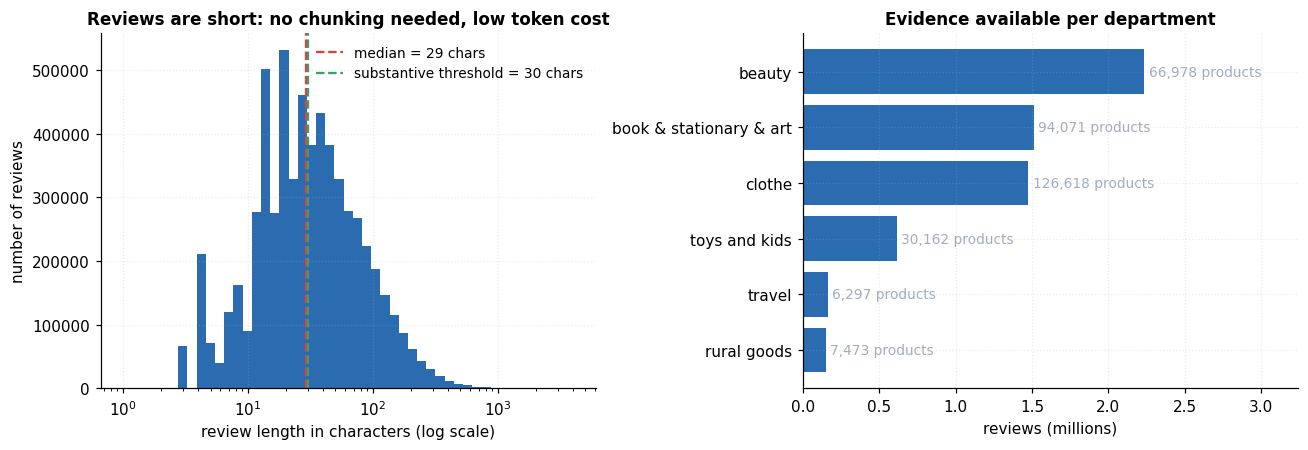

In [ ]:
# --- Figure 5: review length and departments -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
lengths = comments_work["body_len"].loc[comments_work["body_len"] > 0]
ax.hist(lengths, bins=np.logspace(0, np.log10(lengths.max()), 50), color=BLUE)
ax.set_xscale("log")
ax.axvline(lengths.median(), color=RED, linestyle="--",
           label=f"median = {lengths.median():.0f} chars")
ax.axvline(30, color=GREEN, linestyle="--",
           label="substantive threshold = 30 chars")
ax.set_xlabel("review length in characters (log scale)")
ax.set_ylabel("number of reviews")
ax.set_title("Reviews are short: no chunking needed, low token cost")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
by_department = (
    products_work.groupby("sub_category")
    .agg(products=("id", "size"), reviews=("n_reviews", "sum"))
    .sort_values("reviews")
)
positions = np.arange(len(by_department))
ax.barh(positions, by_department["reviews"] / 1e6, color=BLUE)
for y, (name, row) in zip(positions, by_department.iterrows()):
    ax.text(row["reviews"] / 1e6 + 0.03, y,
            f"{row['products']:,} products", va="center", fontsize=9, color=GREY)
ax.set_yticks(positions)
ax.set_yticklabels(by_department.index)
ax.set_xlim(0, by_department["reviews"].max() / 1e6 * 1.45)
ax.set_xlabel("reviews (millions)")
ax.set_title("Evidence available per department")

fig.tight_layout()
save(fig, "fig5_text_and_departments")
plt.show()

In [2]:
from pathlib import Path
import polars as pl
from google.colab import drive

# ۱. نصب پیش‌نیازها
!pip install -q polars pyarrow

# ۲. اتصال مجدد و اجباری به Google Drive
try:
    drive.mount("/content/drive", force_remount=True)
except Exception as e:
    print("درایو قبلاً متصل شده یا خطا داد، ادامه اجرا...")

# ۳. تنظیم مسیرها و ستون‌های مورد نیاز
DATA_DIR = Path("/content/drive/MyDrive")
COMMENTS_WORK_PQ = DATA_DIR / "comments_work.parquet"

NEEDED_COLS = [
    "id", "product_id", "recommendation_status",
    "review_title_norm", "body_norm", "advantages", "disadvantages",
]

# ۴. بارگذاری داده‌ها از فایل Parquet
print("در حال بارگذاری داده‌ها...")
df = pl.read_parquet(str(COMMENTS_WORK_PQ), columns=NEEDED_COLS)
print(f"تعداد کل سطرهای خوانده شده: {df.height:,}")

# ۵. فیلتر کردن برچسب‌های خالی (Null)
df = df.filter(pl.col("recommendation_status").is_not_null())
print(f"تعداد سطرهای دارای برچسب: {df.height:,}")
print("\nتوزیع اولیه برچسب‌ها:")
print(df["recommendation_status"].value_counts())

# ۶. ترکیب بهینه ستون‌های متنی با concat_str
df = df.with_columns(
    pl.concat_str(
        [
            pl.col("review_title_norm").fill_null(""),
            pl.col("body_norm").fill_null(""),
            pl.col("advantages").fill_null(""),
            pl.col("disadvantages").fill_null(""),
        ],
        separator=" ",
    )
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
    .alias("text")
)

# انتخاب ستون‌های نهایی و حذف متن‌های خالی
df = df.select(["id", "product_id", "recommendation_status", "text"])
df = df.filter(pl.col("text").str.len_chars() > 0)
print(f"تعداد سطرها پس از حذف متون خالی: {df.height:,}")

# ۷. تقسیم‌بندی داده‌ها بر اساس product_id
unique_pids = df.select("product_id").unique()
unique_pids = unique_pids.sample(fraction=1.0, shuffle=True, seed=42)

n = unique_pids.height
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train_pids = unique_pids[:n_train]["product_id"]
val_pids = unique_pids[n_train : n_train + n_val]["product_id"]
test_pids = unique_pids[n_train + n_val :]["product_id"]

train_df = df.filter(pl.col("product_id").is_in(train_pids))
val_df = df.filter(pl.col("product_id").is_in(val_pids))
test_df = df.filter(pl.col("product_id").is_in(test_pids))

# ۸. چاپ آمارهای تقسیم‌بندی
print("\n--- آمار تقسیم‌بندی داده‌ها ---")
print(f"Train: {train_df.height:,}  ({train_df.height/df.height*100:.1f}%)")
print(f"Val  : {val_df.height:,}  ({val_df.height/df.height*100:.1f}%)")
print(f"Test : {test_df.height:,}  ({test_df.height/df.height*100:.1f}%)")

print("\n--- توزیع درصد کلاس‌ها در هر بخش ---")
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\nبخش {name}:")
    print(d["recommendation_status"].value_counts(normalize=True))

# ۹. ذخیره خروجی‌ها در درایو
train_df.write_parquet(DATA_DIR / "pred_train.parquet")
val_df.write_parquet(DATA_DIR / "pred_val.parquet")
test_df.write_parquet(DATA_DIR / "pred_test.parquet")

print("\n✅ عملیات با موفقیت انجام شد و فایل‌ها در Google Drive ذخیره شدند.")

Mounted at /content/drive
در حال بارگذاری داده‌ها...
تعداد کل سطرهای خوانده شده: 6,153,060
تعداد سطرهای دارای برچسب: 5,258,990

توزیع اولیه برچسب‌ها:
shape: (3, 2)
┌───────────────────────┬─────────┐
│ recommendation_status ┆ count   │
│ ---                   ┆ ---     │
│ str                   ┆ u32     │
╞═══════════════════════╪═════════╡
│ not_recommended       ┆ 504509  │
│ recommended           ┆ 4160763 │
│ no_idea               ┆ 593718  │
└───────────────────────┴─────────┘
تعداد سطرها پس از حذف متون خالی: 5,258,916


/tmp/ipykernel_1952/4259078241.py:67: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  train_df = df.filter(pl.col("product_id").is_in(train_pids))
/tmp/ipykernel_1952/4259078241.py:68: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  val_df = df.filter(pl.col("product_id").is_in(val_pids))
/tmp/ipykernel_1952/4259078241.py:69: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  test_df = df.filter(pl.col("product_id").is_in(test_pids))



--- آمار تقسیم‌بندی داده‌ها ---
Train: 3,681,531  (70.0%)
Val  : 791,045  (15.0%)
Test : 786,340  (15.0%)

--- توزیع درصد کلاس‌ها در هر بخش ---

بخش Train:
shape: (3, 2)
┌───────────────────────┬────────────┐
│ recommendation_status ┆ proportion │
│ ---                   ┆ ---        │
│ str                   ┆ f64        │
╞═══════════════════════╪════════════╡
│ not_recommended       ┆ 0.095935   │
│ recommended           ┆ 0.791126   │
│ no_idea               ┆ 0.112938   │
└───────────────────────┴────────────┘

بخش Val:
shape: (3, 2)
┌───────────────────────┬────────────┐
│ recommendation_status ┆ proportion │
│ ---                   ┆ ---        │
│ str                   ┆ f64        │
╞═══════════════════════╪════════════╡
│ no_idea               ┆ 0.113727   │
│ recommended           ┆ 0.789758   │
│ not_recommended       ┆ 0.096515   │
└───────────────────────┴────────────┘

بخش Test:
shape: (3, 2)
┌───────────────────────┬────────────┐
│ recommendation_status ┆ proportion │


In [3]:
from pathlib import Path
import time
import gc
import polars as pl
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
import joblib
import json

DATA_DIR = Path("/content/drive/MyDrive")

# ۱. بارگذاری داده‌ها
print("در حال بارگذاری داده‌ها از Parquet...")
train_df = pl.read_parquet(DATA_DIR / "pred_train.parquet")
val_df = pl.read_parquet(DATA_DIR / "pred_val.parquet")
test_df = pl.read_parquet(DATA_DIR / "pred_test.parquet")

# تبدیل به آرایه جهت مدیریت بهتر حافظه
X_train_text = train_df["text"].to_numpy()
y_train = train_df["recommendation_status"].to_numpy()
X_val_text = val_df["text"].to_numpy()
y_val = val_df["recommendation_status"].to_numpy()
X_test_text = test_df["text"].to_numpy()
y_test = test_df["recommendation_status"].to_numpy()

print(f"train: {len(X_train_text):,} | val: {len(X_val_text):,} | test: {len(X_test_text):,}")

# پاکسازی دیتافریم‌های اولیه
del train_df, val_df, test_df
gc.collect()

# ۲. استخراج ویژگی TF-IDF
started = time.time()
print("\nدر حال ساخت ماتریس TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)

print(f"✅ TF-IDF ساخته شد در {time.time()-started:.0f}s | ابعاد ماتریس: {X_train.shape}")

# آزادکردن متون اولیه از RAM به دلیل عدم نیاز در ادامه
del X_train_text, X_val_text, X_test_text
gc.collect()

# ۳. آموزش مدل LinearSVC
started = time.time()
print("\nدر حال آموزش مدل LinearSVC...")
clf = LinearSVC(class_weight="balanced", random_state=42, max_iter=3000)
clf.fit(X_train, y_train)
print(f"✅ آموزش مدل انجام شد در {time.time()-started:.0f}s")

# ۴. ارزیابی مدل روی Validation
val_pred = clf.predict(X_val)
val_macro_f1 = f1_score(y_val, val_pred, average="macro")
print(f"\n=== VALIDATION === Macro F1: {val_macro_f1:.4f}")
print(classification_report(y_val, val_pred, digits=3))

# ۵. ارزیابی مدل روی Test
test_pred = clf.predict(X_test)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")
print(f"\n=== TEST === Macro F1: {test_macro_f1:.4f}")
print(classification_report(y_test, test_pred, digits=3))

print(f"\nمقایسه با baseline اکثریت (0.2945): {'بهتر ✅' if test_macro_f1 > 0.2945 else 'بدتر ❌'}")

# ۶. ذخیره‌سازی فایل‌های خروجی و مدل
print("\nدر حال ذخیره مدل و گزارش‌ها روی Google Drive...")
joblib.dump(vectorizer, DATA_DIR / "tfidf_vectorizer.joblib", compress=3)
joblib.dump(clf, DATA_DIR / "baseline_svc_model.joblib", compress=3)

results = {
    "val_macro_f1": val_macro_f1,
    "test_macro_f1": test_macro_f1,
    "val_report": classification_report(y_val, val_pred, output_dict=True),
    "test_report": classification_report(y_test, test_pred, output_dict=True),
}

with open(DATA_DIR / "baseline_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("✅ ذخیره‌سازی کامل شد:")
print("- tfidf_vectorizer.joblib")
print("- baseline_svc_model.joblib")
print("- baseline_results.json")

در حال بارگذاری داده‌ها از Parquet...
train: 3,681,531 | val: 791,045 | test: 786,340

در حال ساخت ماتریس TF-IDF...
✅ TF-IDF ساخته شد در 157s | ابعاد ماتریس: (3681531, 30000)

در حال آموزش مدل LinearSVC...
✅ آموزش مدل انجام شد در 1010s

=== VALIDATION === Macro F1: 0.7146
                 precision    recall  f1-score   support

        no_idea      0.459     0.492     0.475     89963
not_recommended      0.688     0.788     0.735     76348
    recommended      0.948     0.921     0.934    624734

       accuracy                          0.859    791045
      macro avg      0.698     0.734     0.715    791045
   weighted avg      0.867     0.859     0.863    791045


=== TEST === Macro F1: 0.7153
                 precision    recall  f1-score   support

        no_idea      0.458     0.490     0.473     87953
not_recommended      0.689     0.793     0.738     74968
    recommended      0.949     0.922     0.935    623419

       accuracy                          0.861    786340
      m

In [5]:
import os
import time
import numpy as np
import polars as pl
import torch
from pathlib import Path
from datasets import Dataset
from sklearn.metrics import classification_report, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# ۱. تنظیمات اولیه و پیکربندی دستگاه
DATA_DIR = Path("/content/drive/MyDrive")
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased"
MAX_LENGTH = 160
LABELS = ["recommended", "no_idea", "not_recommended"]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}
RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️ هشدار: GPU فعال نیست! از منوی Runtime > Change runtime type حالت را روی GPU بگذارید.")

# ۲. بارگذاری و نمونه‌گیری هوشمند برای جلوگیری از اتمام سهمیه GPU
print("\nدر حال بارگذاری داده‌ها...")
train_df = pl.read_parquet(DATA_DIR / "pred_train.parquet")
val_df = pl.read_parquet(DATA_DIR / "pred_val.parquet")
test_df = pl.read_parquet(DATA_DIR / "pred_test.parquet")

# نمونه‌گیری متوازن (۱۵ هزار Train و ۳ هزار Val/Test برای سرعت و دقت بالا روی کولب رایگان)
SAMPLE_TRAIN = 15_000
SAMPLE_VAL = 3_000

train_df = train_df.sample(n=min(SAMPLE_TRAIN, train_df.height), seed=RANDOM_STATE)
val_df = val_df.sample(n=min(SAMPLE_VAL, val_df.height), seed=RANDOM_STATE)
test_df = test_df.sample(n=min(SAMPLE_VAL, test_df.height), seed=RANDOM_STATE)

print(f"حجم داده‌های نمونه‌گیری شده -> Train: {train_df.height:,} | Val: {val_df.height:,} | Test: {test_df.height:,}")

# تبدیل لیبل‌ها به ID
def prepare_data(df):
    texts = df["text"].to_list()
    labels = [LABEL2ID[l] for l in df["recommendation_status"].to_list()]
    return Dataset.from_dict({"text": texts, "label": labels})

ds_train = prepare_data(train_df)
ds_val = prepare_data(val_df)
ds_test = prepare_data(test_df)

# ۳. توکنایز کردن متون
print("\nدر حال بارگذاری Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH, padding="max_length")

print("در حال توکنایز کردن داده‌ها...")
ds_train = ds_train.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_val = ds_val.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_test = ds_test.map(tokenize_fn, batched=True, remove_columns=["text"])

# ۴. بارگذاری مدل و تعریف تابع محاسبه معیارها
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"macro_f1": macro_f1}

# ۵. تنظیمات هایپرپارامترهای آموزش
output_dir = DATA_DIR / "bert_persian_model"

training_args = TrainingArguments(
    output_dir=str(output_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=(device == "cuda"), # استفاده از Mixed Precision برای سرعت ۲ برابری و کاهش مصرف VRAM
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

# ۶. شروع آموزش مدل ParsBERT
print("\n🚀 شروع آموزش ParsBERT...")
start_time = time.time()
trainer.train()
print(f"✅ آموزش مدل در {time.time() - start_time:.0f} ثانیه تمام شد.")

# ۷. ارزیابی روی Test Set
print("\n--- ارزیابی مدل نهایی روی Test Set ---")
test_results = trainer.predict(ds_test)
test_preds = np.argmax(test_results.predictions, axis=1)
test_labels = test_results.label_ids

macro_f1 = f1_score(test_labels, test_preds, average="macro")
print(f"\n🎯 Macro F1 (Test): {macro_f1:.4f}")
print(classification_report(test_labels, test_preds, target_names=LABELS, digits=3))

# ذخیره مدل نهایی و توکنایزر روی درایو
trainer.save_model(str(output_dir / "best_checkpoint"))
tokenizer.save_pretrained(str(output_dir / "best_checkpoint"))
print(f"\n✅ مدل نهایی ParsBERT با موفقیت در پوشه {output_dir / 'best_checkpoint'} روی Google Drive ذخیره شد.")

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

در حال بارگذاری داده‌ها...
حجم داده‌های نمونه‌گیری شده -> Train: 15,000 | Val: 3,000 | Test: 3,000

در حال بارگذاری Tokenizer...


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

در حال توکنایز کردن داده‌ها...


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ آموزش مدل در 464 ثانیه تمام شد.

--- ارزیابی مدل نهایی روی Test Set ---



🎯 Macro F1 (Test): 0.7034
                 precision    recall  f1-score   support

    recommended      0.923     0.944     0.934      2354
        no_idea      0.438     0.424     0.431       344
not_recommended      0.807     0.692     0.745       302

       accuracy                          0.859      3000
      macro avg      0.723     0.687     0.703      3000
   weighted avg      0.856     0.859     0.857      3000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ مدل نهایی ParsBERT با موفقیت در پوشه /content/drive/MyDrive/bert_persian_model/best_checkpoint روی Google Drive ذخیره شد.


In [6]:
import os
import time
import gc
import numpy as np
import polars as pl
import torch
from pathlib import Path
from datasets import Dataset
from sklearn.metrics import classification_report, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

# ۱. مسیرها و تنظیمات
DATA_DIR = Path("/content/drive/MyDrive")
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased"
MAX_LENGTH = 160
LABELS = ["recommended", "no_idea", "not_recommended"]
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for label, i in LABEL2ID.items()}
RANDOM_STATE = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ۲. بارگذاری و نمونه‌گیری ۲۰۰ هزارتایی
print("\nدر حال بارگذاری داده‌ها...")
train_df = pl.read_parquet(DATA_DIR / "pred_train.parquet")
val_df = pl.read_parquet(DATA_DIR / "pred_val.parquet")
test_df = pl.read_parquet(DATA_DIR / "pred_test.parquet")

SAMPLE_TRAIN = 200_000
SAMPLE_VAL = 15_000

train_df = train_df.sample(n=min(SAMPLE_TRAIN, train_df.height), seed=RANDOM_STATE)
val_df = val_df.sample(n=min(SAMPLE_VAL, val_df.height), seed=RANDOM_STATE)
test_df = test_df.sample(n=min(SAMPLE_VAL, test_df.height), seed=RANDOM_STATE)

print(f"حجم داده‌ها -> Train: {train_df.height:,} | Val: {val_df.height:,} | Test: {test_df.height:,}")

# تبدیل به فرمت Dataset
def prepare_data(df):
    texts = df["text"].to_list()
    labels = [LABEL2ID[l] for l in df["recommendation_status"].to_list()]
    return Dataset.from_dict({"text": texts, "label": labels})

ds_train = prepare_data(train_df)
ds_val = prepare_data(val_df)
ds_test = prepare_data(test_df)

del train_df, val_df, test_df
gc.collect()

# ۳. توکنایز کردن متون
print("\nدر حال توکنایز کردن متون...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH, padding="max_length")

ds_train = ds_train.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_val = ds_val.map(tokenize_fn, batched=True, remove_columns=["text"])
ds_test = ds_test.map(tokenize_fn, batched=True, remove_columns=["text"])

# ۴. بارگذاری مدل ParsBERT
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"macro_f1": macro_f1}

# ۵. تنظیمات آموزش امن و بهینه
output_dir = DATA_DIR / "bert_persian_200k"

training_args = TrainingArguments(
    output_dir=str(output_dir),
    eval_strategy="steps",
    eval_steps=1500,                  # ارزیابی متناوب
    save_steps=1500,                  # ذخیره چک‌پوینت روی درایو
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=32,   # افزایش سرعت آموزش
    per_device_eval_batch_size=64,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    fp16=(device == "cuda"),           # کاهش ۵۰ درصدی مصرف VRAM و ۲ برابر شدن سرعت
    logging_steps=300,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# ۶. شروع آموزش
print("\n🚀 شروع آموزش ParsBERT روی ۲۰۰ هزار داده...")
start_time = time.time()
trainer.train()
print(f"✅ آموزش مدل در {(time.time() - start_time)/60:.1f} دقیقه تمام شد.")

# ۷. ارزیابی نهایی
print("\n--- ارزیابی روی Test Set ---")
test_results = trainer.predict(ds_test)
test_preds = np.argmax(test_results.predictions, axis=1)
test_labels = test_results.label_ids

macro_f1 = f1_score(test_labels, test_preds, average="macro")
print(f"\n🎯 Macro F1 (Test): {macro_f1:.4f}")
print(classification_report(test_labels, test_preds, target_names=LABELS, digits=3))

# ذخیره‌سازی مدل نهایی
final_path = output_dir / "best_model_200k"
trainer.save_model(str(final_path))
tokenizer.save_pretrained(str(final_path))
print(f"\n✅ مدل نهایی با موفقیت در پوشه {final_path} ذخیره شد.")

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

در حال بارگذاری داده‌ها...
حجم داده‌ها -> Train: 200,000 | Val: 15,000 | Test: 15,000

در حال توکنایز کردن متون...


Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ آموزش مدل در 40.2 دقیقه تمام شد.

--- ارزیابی روی Test Set ---



🎯 Macro F1 (Test): 0.7210
                 precision    recall  f1-score   support

    recommended      0.934     0.961     0.947     11809
        no_idea      0.516     0.411     0.457      1716
not_recommended      0.756     0.761     0.759      1475

       accuracy                          0.878     15000
      macro avg      0.735     0.711     0.721     15000
   weighted avg      0.869     0.878     0.872     15000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ مدل نهایی با موفقیت در پوشه /content/drive/MyDrive/bert_persian_200k/best_model_200k ذخیره شد.


In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "/content/drive/MyDrive/bert_persian_200k/best_model_200k"

# بارگذاری مدل و توکنایزر از درایو
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# تست با متون نمونه
test_samples = [
    "کیفیت ساخت عالی بود ولی قیمتش نسبت به بازار کمی بالاست",
    "کلا پیشنهاد نمیکنم بعد از دو روز استفاده خرابی پیدا کرد",
    "معمولی هستش نه خیلی بده نه خیلی خوب"
]

labels = ["recommended", "no_idea", "not_recommended"]

for text in test_samples:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=160).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        pred_id = torch.argmax(probs, dim=-1).item()

    print(f"متن: {text}")
    print(f"پیش‌بینی: {labels[pred_id]} (احتمال: {probs[0][pred_id]:.2f})\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

متن: کیفیت ساخت عالی بود ولی قیمتش نسبت به بازار کمی بالاست
پیش‌بینی: recommended (احتمال: 0.92)

متن: کلا پیشنهاد نمیکنم بعد از دو روز استفاده خرابی پیدا کرد
پیش‌بینی: not_recommended (احتمال: 0.94)

متن: معمولی هستش نه خیلی بده نه خیلی خوب
پیش‌بینی: no_idea (احتمال: 0.68)



In [1]:
import json
import numpy as np
import polars as pl
import torch
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive")
LABELS = ["recommended", "no_idea", "not_recommended"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}

with open(DATA_DIR / "baseline_results.json", encoding="utf-8") as f:
    baseline_results = json.load(f)
baseline_test_f1 = baseline_results["test_macro_f1"]

# کپی مدل به دیسک محلی کولب (خیلی سریع‌تر از خوندن مستقیم از Drive)
!mkdir -p /content/local_model
!cp -r "/content/drive/MyDrive/bert_persian_200k/best_model_200k/"* /content/local_model/

MODEL_PATH = "/content/local_model"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

test_df = pl.read_parquet(DATA_DIR / "pred_test.parquet")

EVAL_SAMPLE = 100_000
if test_df.height > EVAL_SAMPLE:
    frac = EVAL_SAMPLE / test_df.height
    test_df = (
        test_df.group_by("recommendation_status")
        .map_groups(lambda g: g.sample(fraction=frac, seed=42))
    )
print(f"نمونه‌ی ارزیابی: {test_df.height:,}")

texts = test_df["text"].to_list()
true_labels = [LABEL2ID[s] for s in test_df["recommendation_status"].to_list()]
del test_df

BATCH = 64
all_preds = []
with torch.no_grad():
    for i in range(0, len(texts), BATCH):
        batch_texts = texts[i:i + BATCH]
        enc = tokenizer(batch_texts, truncation=True, max_length=160,
                         padding=True, return_tensors="pt").to(device)
        logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        del enc, logits, preds
        if i % (BATCH * 200) == 0:
            print(f"{i:,}/{len(texts):,}")
            if device == "cuda":
                torch.cuda.empty_cache()

parsbert_test_f1 = f1_score(true_labels, all_preds, average="macro")
print(f"\nParsBERT(200k) Macro F1 روی نمونه‌ی test ({len(texts):,}): {parsbert_test_f1:.4f}")
print(classification_report(true_labels, all_preds, target_names=LABELS, digits=3))

print("\n" + "=" * 50)
print("جدول مقایسه‌ی نهایی مدل‌ها")
print("=" * 50)
print(f"{'مدل':<30}{'Macro F1 (Test)':<15}")
print(f"{'TF-IDF + LinearSVC (Baseline)':<30}{baseline_test_f1:<15.4f}")
print(f"{'ParsBERT (200k sample)':<30}{parsbert_test_f1:<15.4f}")
improvement = (parsbert_test_f1 - baseline_test_f1) / baseline_test_f1 * 100
print(f"\nبهبود ParsBERT نسبت به Baseline: {improvement:+.1f}%")

cm = confusion_matrix(true_labels, all_preds)
print("\nConfusion Matrix (ردیف=واقعی, ستون=پیش‌بینی):")
print(f"{'':>18}", *[f"{l:>16}" for l in LABELS])
for i, row in enumerate(cm):
    print(f"{LABELS[i]:>18}", *[f"{v:>16,}" for v in row])

errors = [
    (texts[i], LABELS[true_labels[i]], LABELS[all_preds[i]])
    for i in range(len(texts)) if true_labels[i] != all_preds[i]
]
print(f"\nتعداد کل خطاها: {len(errors):,} از {len(texts):,}")
print("\nنمونه‌ی ۵ خطای تصادفی:")
import random
random.seed(42)
for text, true_l, pred_l in random.sample(errors, 5):
    print(f"واقعی: {true_l:<18} پیش‌بینی: {pred_l:<18} متن: {text[:100]}")

final_comparison = {
    "baseline_test_macro_f1": baseline_test_f1,
    "parsbert_200k_test_macro_f1": parsbert_test_f1,
    "improvement_pct": improvement,
    "confusion_matrix": cm.tolist(),
    "labels": LABELS,
}
with open(DATA_DIR / "final_model_comparison.json", "w", encoding="utf-8") as f:
    json.dump(final_comparison, f, ensure_ascii=False, indent=2)
print("\nذخیره شد: final_model_comparison.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

نمونه‌ی ارزیابی: 99,999
0/99,999
12,800/99,999
25,600/99,999
38,400/99,999
51,200/99,999
64,000/99,999
76,800/99,999
89,600/99,999

ParsBERT(200k) Macro F1 روی نمونه‌ی test (99,999): 0.7248
                 precision    recall  f1-score   support

    recommended      0.936     0.959     0.947     79281
        no_idea      0.527     0.427     0.472     11185
not_recommended      0.749     0.763     0.756      9533

       accuracy                          0.881     99999
      macro avg      0.737     0.716     0.725     99999
   weighted avg      0.872     0.881     0.876     99999


جدول مقایسه‌ی نهایی مدل‌ها
مدل                           Macro F1 (Test)
TF-IDF + LinearSVC (Baseline) 0.7153         
ParsBERT (200k sample)        0.7248         

بهبود ParsBERT نسبت به Baseline: +1.3%

Confusion Matrix (ردیف=واقعی, ستون=پیش‌بینی):
                        recommended          no_idea  not_recommended
       recommended           76,028            2,670              583
           no_i